In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [4]:
# Path to your CSV (no headers)
csv_path = "TPU14-PEO21.csv"

# Read CSV with no header row
df = pd.read_csv(
    csv_path,
    sep=";",
    header=None,
    names=["Category", "Tag", "Timestamp", "Value"],
    decimal="."            # important for numeric parsing
)

# Parse timestamp format: DD.MM.YYYY HH:MM:SS.sss
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    format="%d.%m.%Y %H:%M:%S.%f",
    errors="coerce"
)

# Clean
df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp")
print(df["Tag"].unique())

<StringArray>
['FT616 Packed Tower Water Flow (41)',              'FT617 Weir Water Flow',
               'Equipment Status (2)']
Length: 3, dtype: str


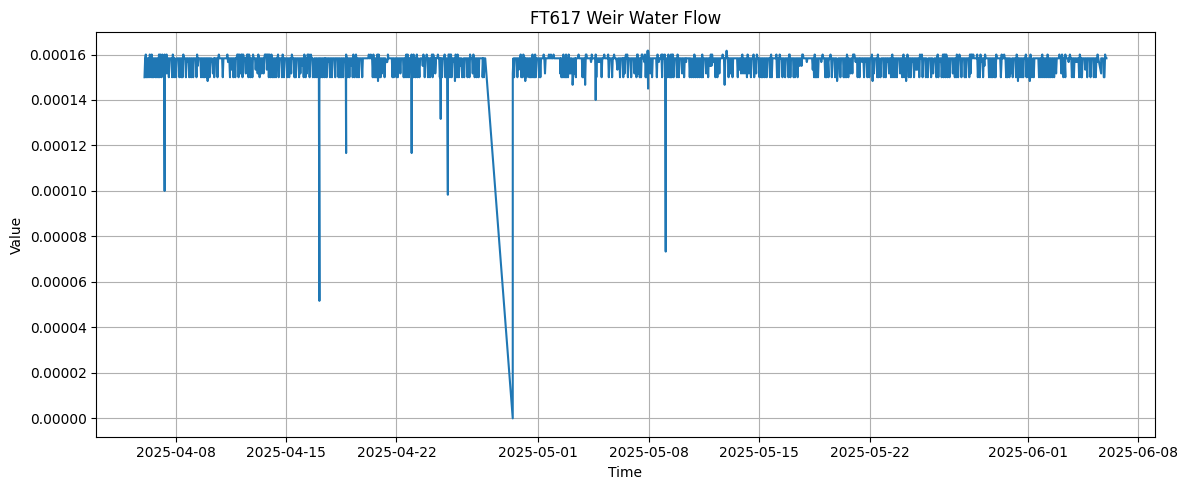

In [5]:
tag = "FT617 Weir Water Flow"
df_tag = df[df["Tag"] == tag]

plt.figure(figsize=(12, 5))
plt.plot(df_tag["Timestamp"], df_tag["Value"], linewidth=1.5)
plt.title(tag)
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()